# Разбор моделей на размеченной сотне рядов

Сто рядов с известными позициями сломов, прогнанные ровно так, как это делает
платформа — по одной точке, без заглядывания вперёд. Оцениваются все три
сильные модели: **005** (40 каналов), **006** (41, +свёрточный канал),
**008** (50, +ревертируемые каналы — текущая лучшая).

Каждая картинка устроена одинаково, сверху вниз:

1. **сырой ряд** — серая история (слома нет по условию) и синяя онлайн-часть;
2. **нормированный ряд** — то, что реально видят детекторы: минус тренд,
   минус масштаб, обрезка выбросов;
3. **три узкие полосы — по одной на модель**: счёт от 0 до 1, в том числе на
   истории (пунктиром) — видно, дёргалась ли модель там, где слома
   гарантированно нет. Точка — где модель «решила», что слом был; у 008
   оранжевые треугольники — отмены тревоги;
4. **компоненты** — отдельные детекторы, из которых складывается счёт.

Вертикальные линии на всех полосах: серая — граница история/онлайн, красная
пунктирная — истинный слом из разметки.

Счёт на истории — иллюстративный прогон: на платформе модель историю не
оценивает, и на границе (t = 0) детекторы начинают с чистого листа, как в бою.
Свёрточный канал на истории не пересчитывается и стоит на 0.5.

Сначала галереи по качеству (лучшие, середина, худшие), затем срезы по
характеру ряда — оттуда берутся гипотезы для следующей модели.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

WS = Path("../../structural-break-real-time-test")
sys.path.insert(0, str(WS))

import importlib.util
spec = importlib.util.spec_from_file_location(
    "submission", Path("../submissions/008-reverting-channels/main.py")
)
submission = importlib.util.module_from_spec(spec)
# Регистрация до исполнения: модуль объявляет dataclass-ы, а разрешение их
# полей ищет модуль в sys.modules — без регистрации падает с AttributeError.
sys.modules["submission"] = submission
spec.loader.exec_module(submission)

x = pd.read_parquet(WS / "data/X_test.reduced.parquet")
y = pd.read_parquet(WS / "data/y_test.reduced.parquet")
models = {
    "005": joblib.load("../../model005_backup.joblib")["booster"],    # 40 каналов
    "006": joblib.load("../../model006.joblib")["booster"],           # 41, +CNN
    "008": joblib.load("../../resources008/model.joblib")["booster"], # 50, +ревертируемые
}
model = models["008"]  # лучшая: сортировка и метрики считаются по ней
print(f"рядов: {x.index.get_level_values(0).nunique()}; каналов у моделей:",
      {k: m.n_features_ for k, m in models.items()})

рядов: 100; каналов у моделей: {'005': 40, '006': 41, '008': 50}


In [2]:
# Прогоняем каждый ряд по шагам и складываем всё, что нужно картинкам.
records = {}
for sid, part in x.groupby(level="id"):
    hist = part.loc[part.period == 1, "value"].to_numpy()
    online = part.loc[part.period == 2, "value"].to_numpy()
    if len(online) == 0:
        continue
    labels = y.loc[sid, "target"].to_numpy()

    # Онлайн-прогон — ровно как на платформе.
    monitor = submission.Monitor(hist)
    channels = np.asarray([monitor.update(float(v)) for v in online])
    # Первые 40 колонок — вектор 005, первые 41 — 006: порядок каналов только
    # дописывался в конец, так что одна прогонка кормит все модели.
    all_scores = {
        name: m.predict_proba(channels[:, : m.n_features_])[:, 1]
        for name, m in models.items()
    }
    scores = all_scores["008"]

    # Иллюстративный прогон по истории: те же детекторы, шаги -n..-1, тренд
    # снимается в своей точке. На платформе этого прогона нет; свёрточный
    # канал здесь не пересчитывается и стоит на 0.5.
    playback = submission.Monitor(hist)
    playback._step = -len(hist)
    playback._previous_z = 0.0
    hist_channels = np.asarray([playback.update(float(v)) for v in hist])
    hist_scores = {
        name: m.predict_proba(hist_channels[:, : m.n_features_])[:, 1]
        for name, m in models.items()
    }

    norm = monitor.norm
    z_online = np.asarray(
        [norm.clip(norm.standardise(float(v), i)) for i, v in enumerate(online)]
    )
    z_hist = np.asarray(
        [norm.clip(norm.standardise(float(v), -len(hist) + i)) for i, v in enumerate(hist)]
    )
    tau = int(labels.argmax()) if labels.max() > 0 else None

    # Где модель сама «решила», что слом был: первый шаг, на котором её счёт
    # пересёк половину своего максимума по этому ряду. Условность для глаза —
    # метрика точку не спрашивает.
    detected_by = {}
    for name, sc in all_scores.items():
        peak = float(sc.max())
        crossed = np.flatnonzero(sc >= 0.5 * peak) if peak > 0 else []
        detected_by[name] = int(crossed[0]) if len(crossed) else None
    detected = detected_by["008"]

    # Отмена тревоги (умеет только 008): счёт падает ниже половины своего
    # достигнутого максимума после того, как тревога была поднята всерьёз.
    running = np.maximum.accumulate(scores)
    alarmed = running >= 0.6 * float(scores.max()) if scores.max() > 0 else running > 1
    below = scores < 0.5 * running
    cross_down = below & ~np.roll(below, 1) & alarmed
    cross_down[0] = False
    cancellations = np.flatnonzero(cross_down)

    records[int(sid)] = dict(
        hist=hist, online=online, z=z_online, z_hist=z_hist, scores=scores,
        channels=channels,
        labels=labels, tau=tau, detected=detected,
        all_scores=all_scores, hist_scores=hist_scores,
        detected_by=detected_by, cancellations=cancellations,
        slope=norm.slope, sd=norm.sd, rho=norm.rho, kurt=norm.kurtosis,
    )
print(f"прогнано рядов: {len(records)}")

прогнано рядов: 100


In [3]:
# Качество по рядам. Для ряда со сломом: AUC внутри ряда — ставит ли счёт
# шаги после слома выше шагов до. Для ряда без слома: уровень ложной тревоги,
# взятый как финальный счёт (ниже — лучше). Вопросы разные, поэтому галереи
# сортируются раздельно. Всё считается по лучшей модели (008).
def within_auc(scores, labels):
    pos, neg = scores[labels == 1], scores[labels == 0]
    if len(pos) == 0 or len(neg) == 0:
        return np.nan
    ranks = np.concatenate([pos, neg]).argsort().argsort() + 1
    return (ranks[: len(pos)].sum() - len(pos) * (len(pos) + 1) / 2) / (len(pos) * len(neg))

rows = []
for sid, r in records.items():
    rows.append(dict(
        id=sid, broken=r["tau"] is not None, tau=r["tau"],
        n_online=len(r["online"]),
        quality=within_auc(r["scores"], r["labels"]) if r["tau"] is not None else np.nan,
        false_alarm=float(r["scores"][-1]) if r["tau"] is None else np.nan,
        trend=abs(r["slope"]) * len(r["hist"]) / r["sd"],
        sd=r["sd"], rho=r["rho"], kurt=r["kurt"],
    ))
table = pd.DataFrame(rows).set_index("id")
# Глубина отката: насколько счёт 008 умеет спуститься после подъёма.
table["drawdown"] = [
    float((np.maximum.accumulate(records[sid]["scores"]) - records[sid]["scores"]).max())
    for sid in table.index
]
broken = table[table.broken].sort_values("quality", ascending=False)
clean = table[~table.broken].sort_values("false_alarm")
print(f"рядов со сломом: {len(broken)}, без слома: {len(clean)}")
print(f"со сломом: медианный AUC внутри ряда {broken.quality.median():.3f}")
print(f"без слома: медианный финальный счёт {clean.false_alarm.median():.3f}")

рядов со сломом: 53, без слома: 47
со сломом: медианный AUC внутри ряда 0.973
без слома: медианный финальный счёт 0.320


In [4]:
MODEL_STYLE = {
    "005": ("40 каналов", "#5f6368"),
    "006": ("41 канал, +свёрточный", "#1a73e8"),
    "008": ("50 каналов, +ревертируемые — ЛУЧШАЯ", "#7b1fa2"),
}

def show(sid, title_extra=""):
    r = records[sid]
    hist, online, z, scores, tau = r["hist"], r["online"], r["z"], r["scores"], r["tau"]
    z_hist, detected = r["z_hist"], r["detected"]
    all_scores, hist_scores = r["all_scores"], r["hist_scores"]
    detected_by, cancellations = r["detected_by"], r["cancellations"]
    n_h = len(hist)
    ch = r["channels"]
    fig, axes = plt.subplots(6, 1, figsize=(11, 11), sharex=True,
                             gridspec_kw=dict(height_ratios=[2, 1.2, 0.75, 0.75, 0.95, 1.5]))
    t_hist = np.arange(-n_h, 0)
    t_on = np.arange(len(online))

    axes[0].plot(t_hist[-600:], hist[-600:], lw=0.6, color="#9aa0a6",
                 label="история (слома нет по условию)")
    axes[0].plot(t_on, online, lw=0.8, color="#1a73e8",
                 label="онлайн-часть (приходит по одной точке)")
    axes[0].set_ylabel("сырой ряд")

    axes[1].plot(t_hist[-600:], z_hist[-600:], lw=0.6, color="#9aa0a6",
                 label="история после нормировки (для сравнения масштаба)")
    axes[1].plot(t_on, z, lw=0.8, color="#188038",
                 label="онлайн после нормировки: минус тренд, минус масштаб, обрезка выбросов")
    axes[1].axhline(0, color="grey", lw=0.5)
    axes[1].set_ylabel("нормированный")

    # По узкой полосе на модель: счёт на истории пунктиром, онлайн сплошной,
    # точка — где эта модель сработала, у 008 — треугольники отмен тревоги.
    for k, (name, (label, colour)) in enumerate(MODEL_STYLE.items()):
        ax = axes[2 + k]
        sc, hs = all_scores[name], hist_scores[name]
        ax.plot(t_hist[-600:], hs[-600:], lw=0.8, color=colour, ls=":", alpha=0.7,
                label="на истории (иллюстративно)")
        ax.plot(t_on, sc, lw=1.3, color=colour, label=f"модель {name}: {label}")
        if detected_by[name] is not None:
            d = detected_by[name]
            ax.plot(d, sc[d], "o", ms=6, color=colour, zorder=5,
                    label="здесь модель сработала")
            ax.axvline(d, color=colour, lw=0.8, alpha=0.35)
        if name == "008" and len(cancellations):
            ax.plot(cancellations, sc[cancellations], "v", ms=8,
                    color="#f9ab00", zorder=6, label="ОТМЕНА тревоги")
        ax.set_ylim(-0.02, 1.02)
        ax.set_ylabel(name)

    comp = [
        ("CUSUM (сдвиг уровня, макс. по 3 видам)", ch[:, [0, 3, 6]].max(axis=1), "#1a73e8"),
        ("Page-Hinkley (медленный дрейф)", ch[:, [1, 4, 7]].max(axis=1), "#188038"),
        ("Variance-ratio (изменение разброса)", ch[:, [2, 5, 8]].max(axis=1), "#d93025"),
        ("Multiscale: текущее расхождение", ch[:, 9:21].max(axis=1), "#f9ab00"),
        ("Multiscale: пик за всё время", ch[:, 21:33].max(axis=1), "#9334e6"),
        ("Ретроскан лучшего разбиения", ch[:, 33], "#5f6368"),
    ]
    for name, series_c, colour in comp:
        axes[5].plot(t_on, series_c, lw=1.0, color=colour, label=name, alpha=0.9)
    axes[5].set_ylim(-0.02, 1.02)
    axes[5].set_ylabel("компоненты")
    axes[5].set_xlabel("шаг онлайн-части (история — при отрицательных t)")

    for k, ax in enumerate(axes):
        ax.axvline(0, color="grey", lw=1.0, alpha=0.6,
                   label="граница история/онлайн" if k == 0 else None)
        if tau is not None:
            ax.axvline(tau, color="#d93025", lw=1.2, ls="--",
                       label="ИСТИННЫЙ слом (разметка)" if k == 0 else None)
        ax.legend(loc="upper left", fontsize=7, ncols=2 if k in (0, 1, 5) else 3,
                  frameon=True, framealpha=0.85)
    q = table.loc[sid]
    status = f"слом на шаге {tau}" if tau is not None else "слома нет"
    metric = (f"AUC внутри ряда {q.quality:.3f}" if tau is not None
              else f"финальный счёт {q.false_alarm:.3f}")
    fig.suptitle(f"ряд {sid} — {status} — {metric}{title_extra}", y=0.995)
    plt.tight_layout()
    plt.show()

## Ряды со сломом: лучшие, середина, худшие

Красный пунктир — истинный слом. Вопрос к каждой картинке: счёт поднимается
*на* красной линии, позже — или вообще не поднимается.

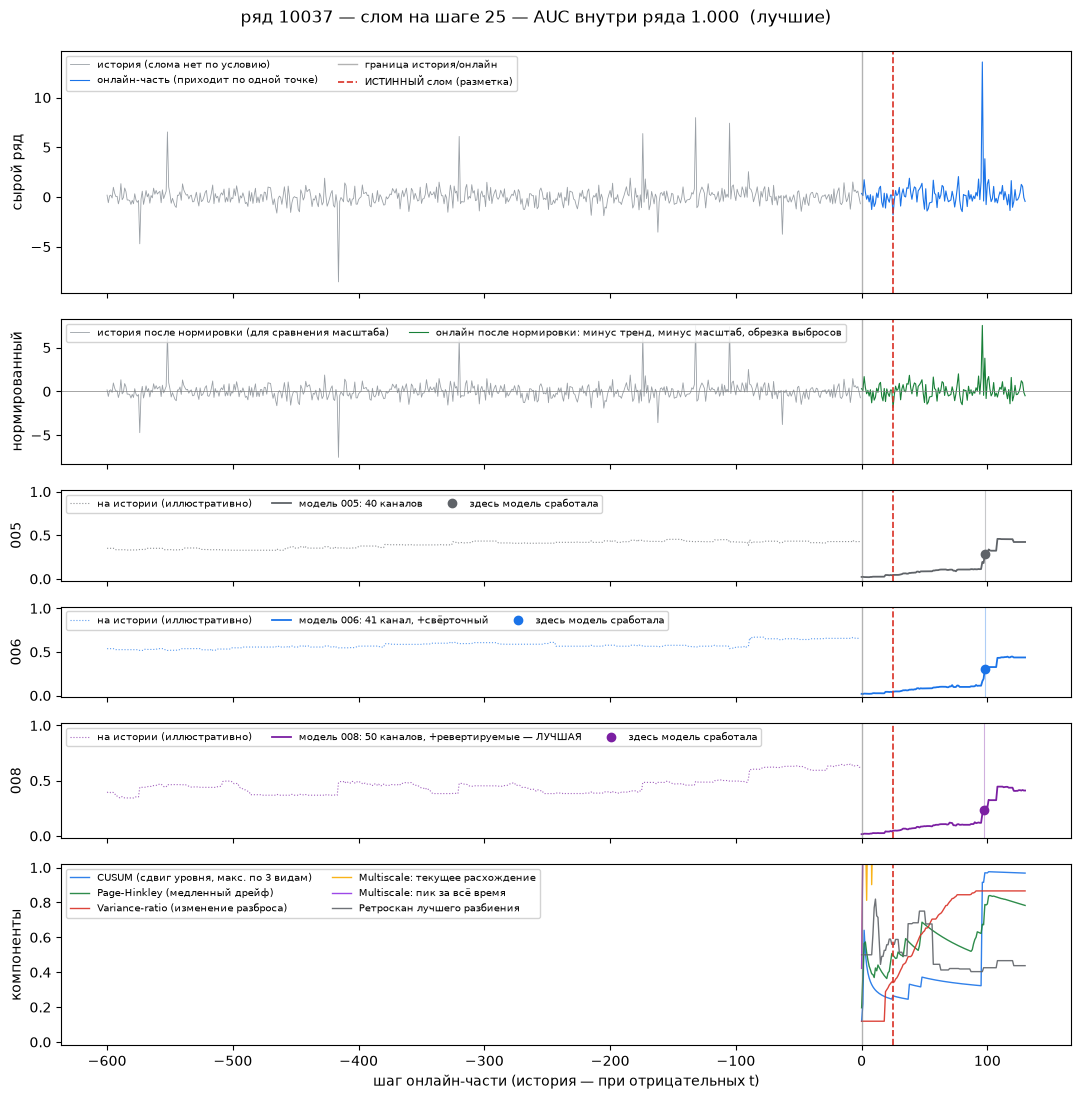

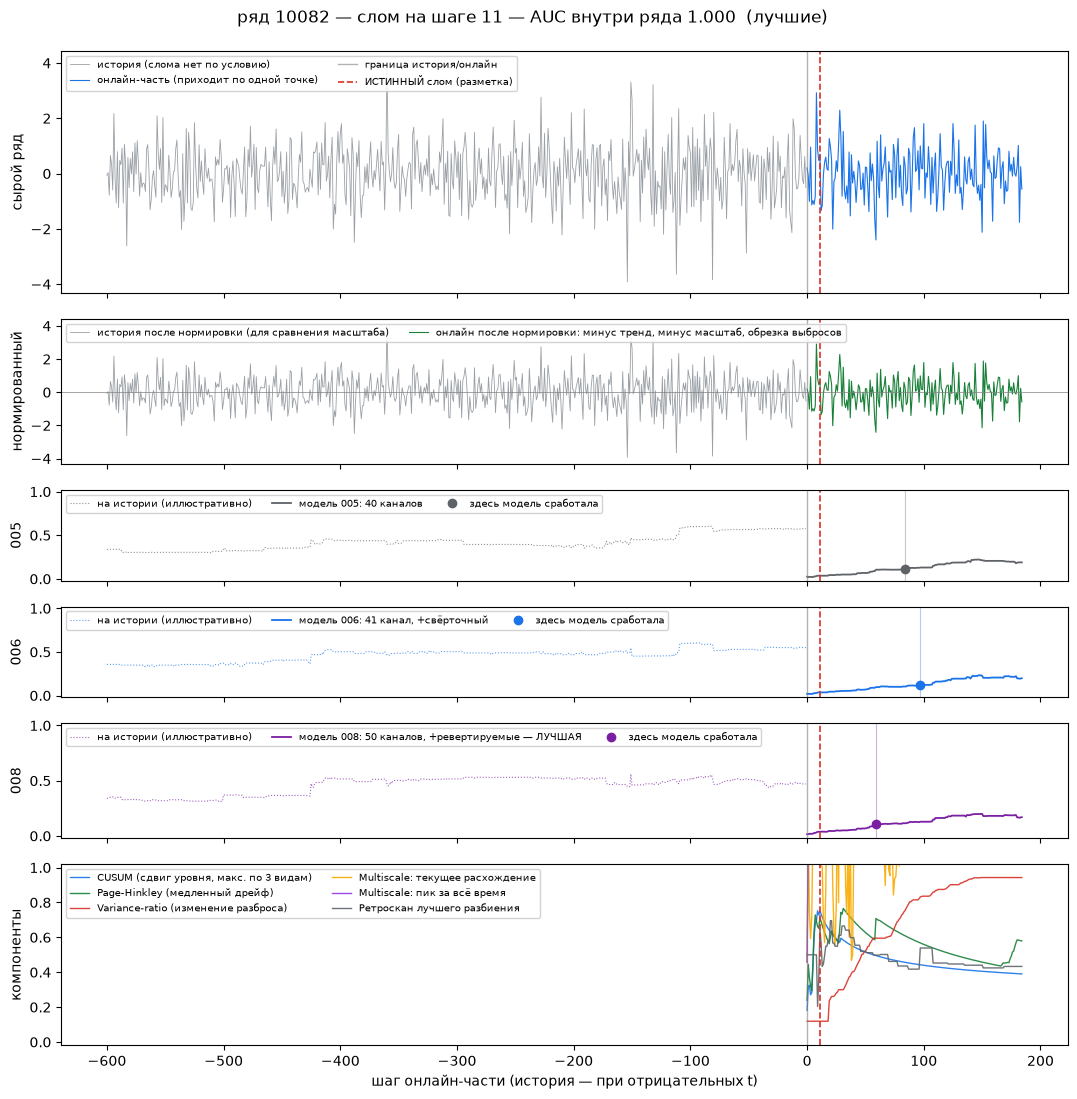

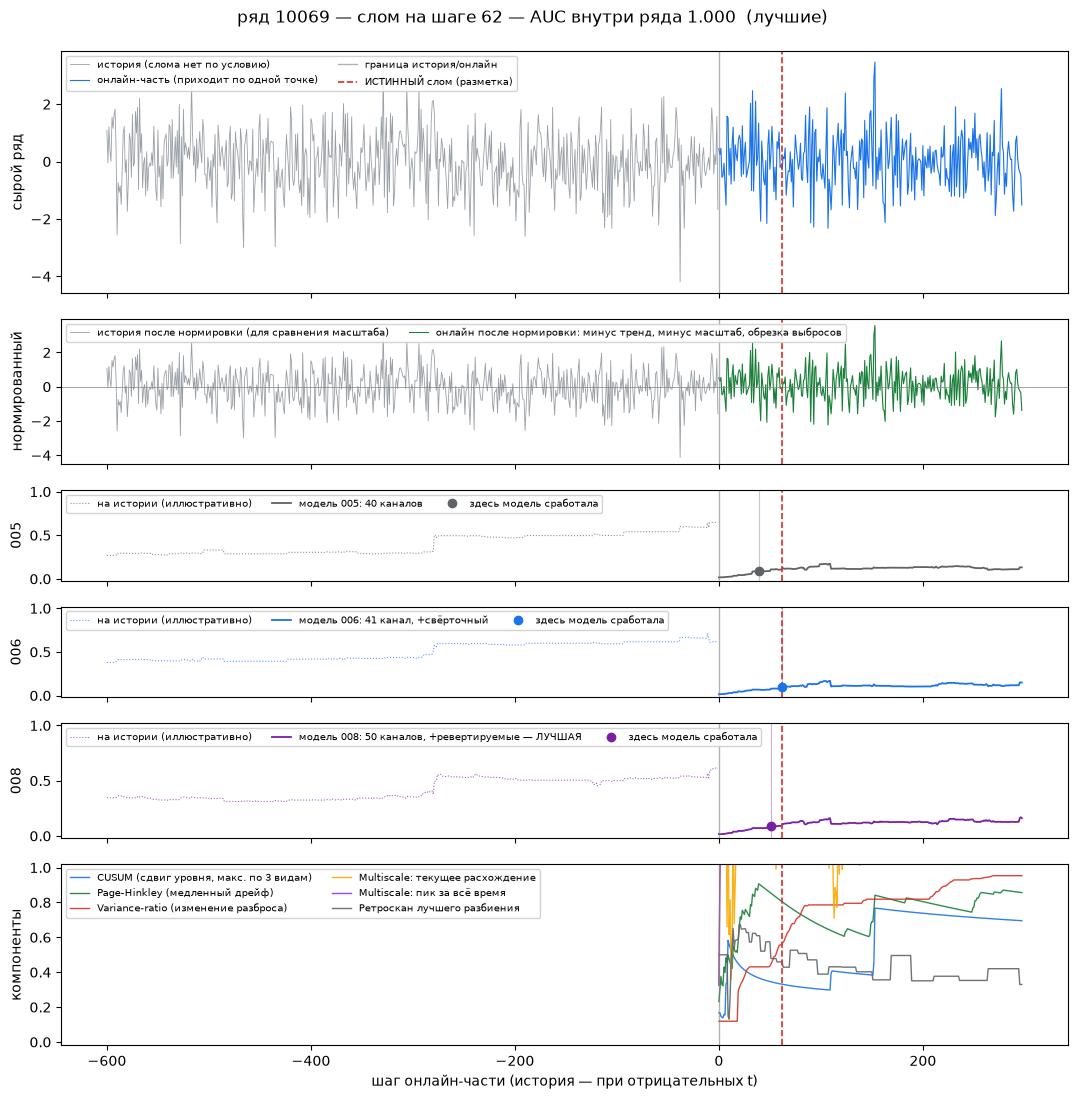

In [5]:
ids = list(broken.index)
for sid in ids[:3]:
    show(sid, "  (лучшие)")

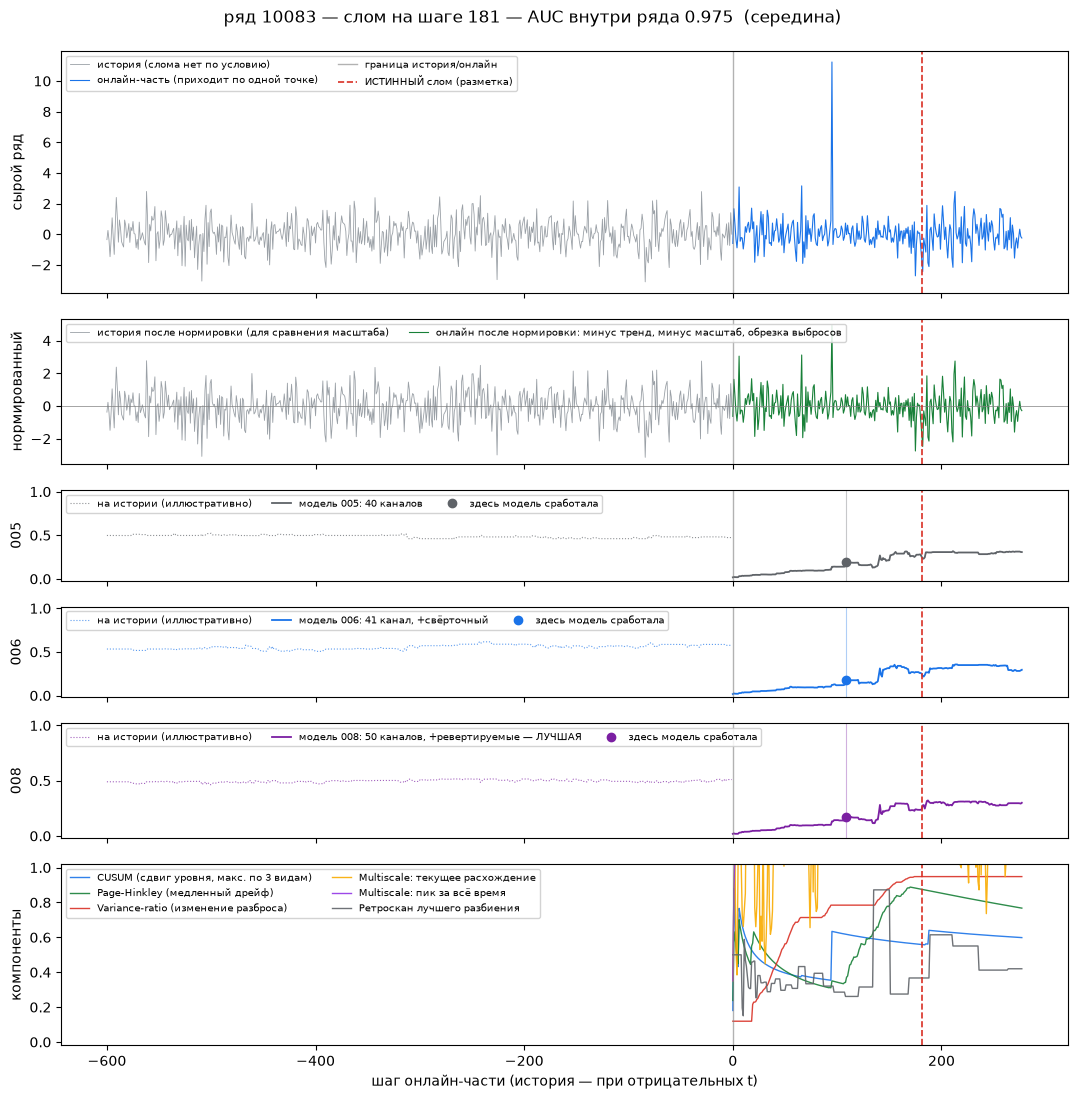

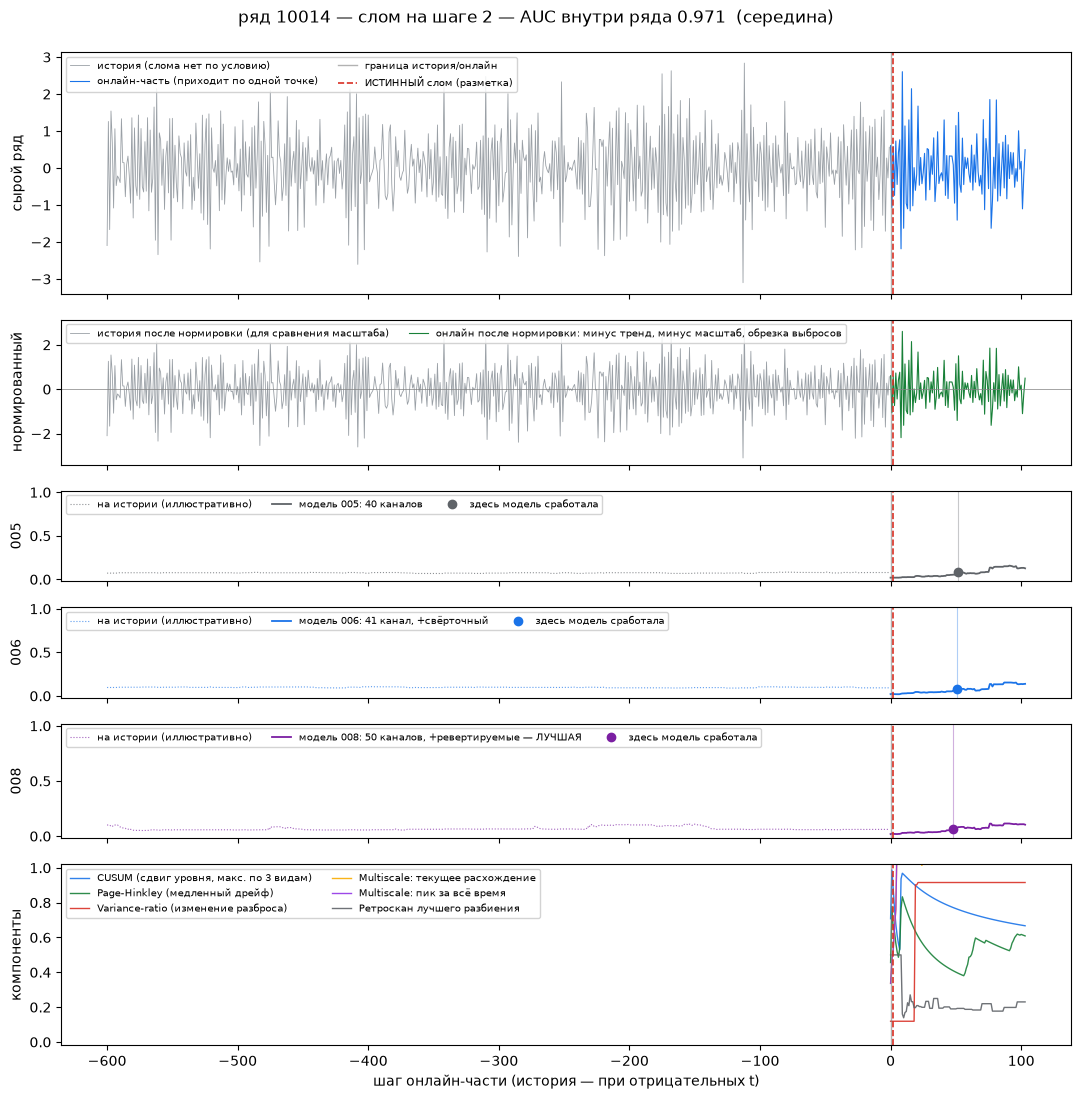

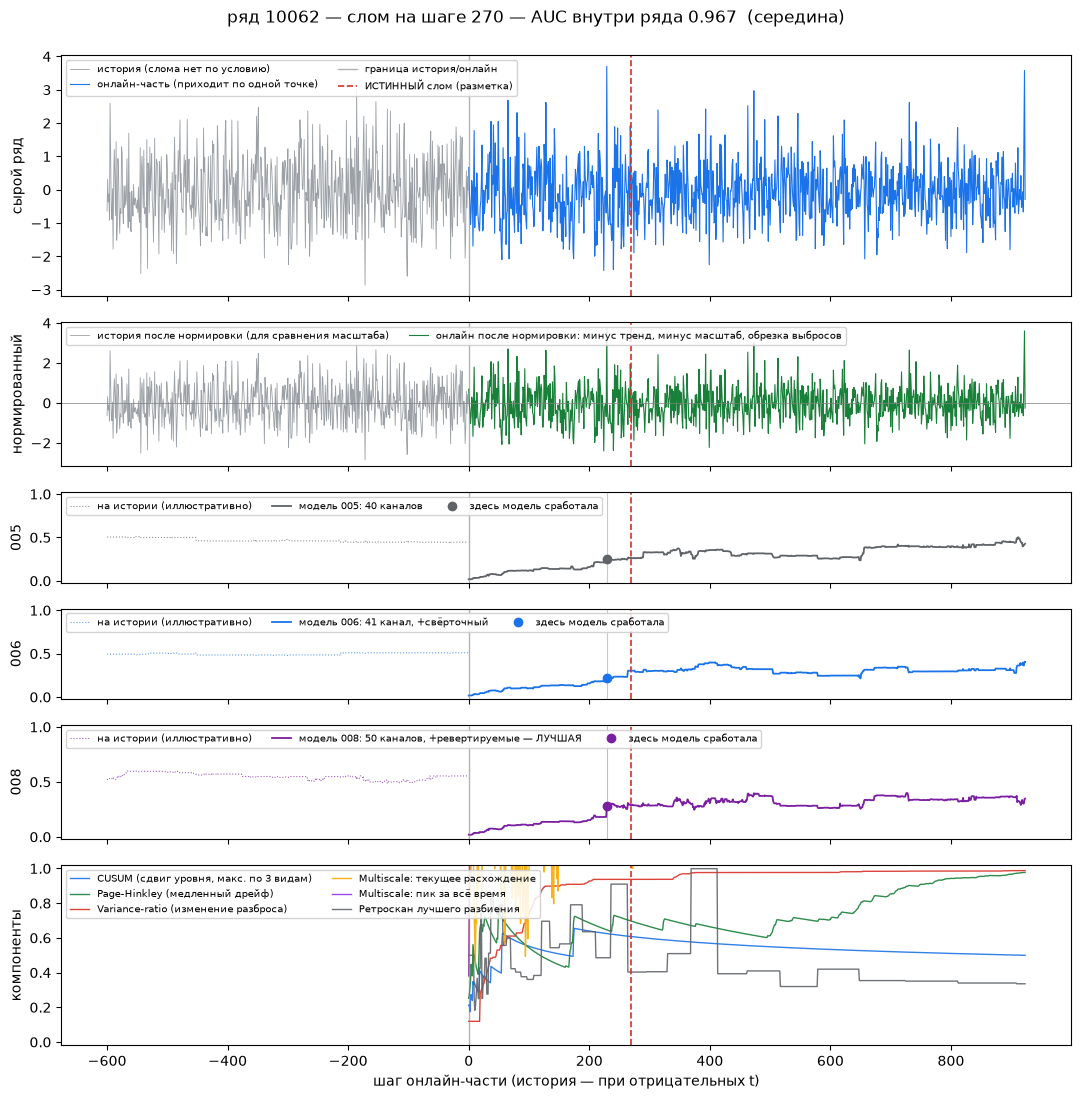

In [6]:
mid = len(ids) // 2
for sid in ids[mid - 1 : mid + 2]:
    show(sid, "  (середина)")

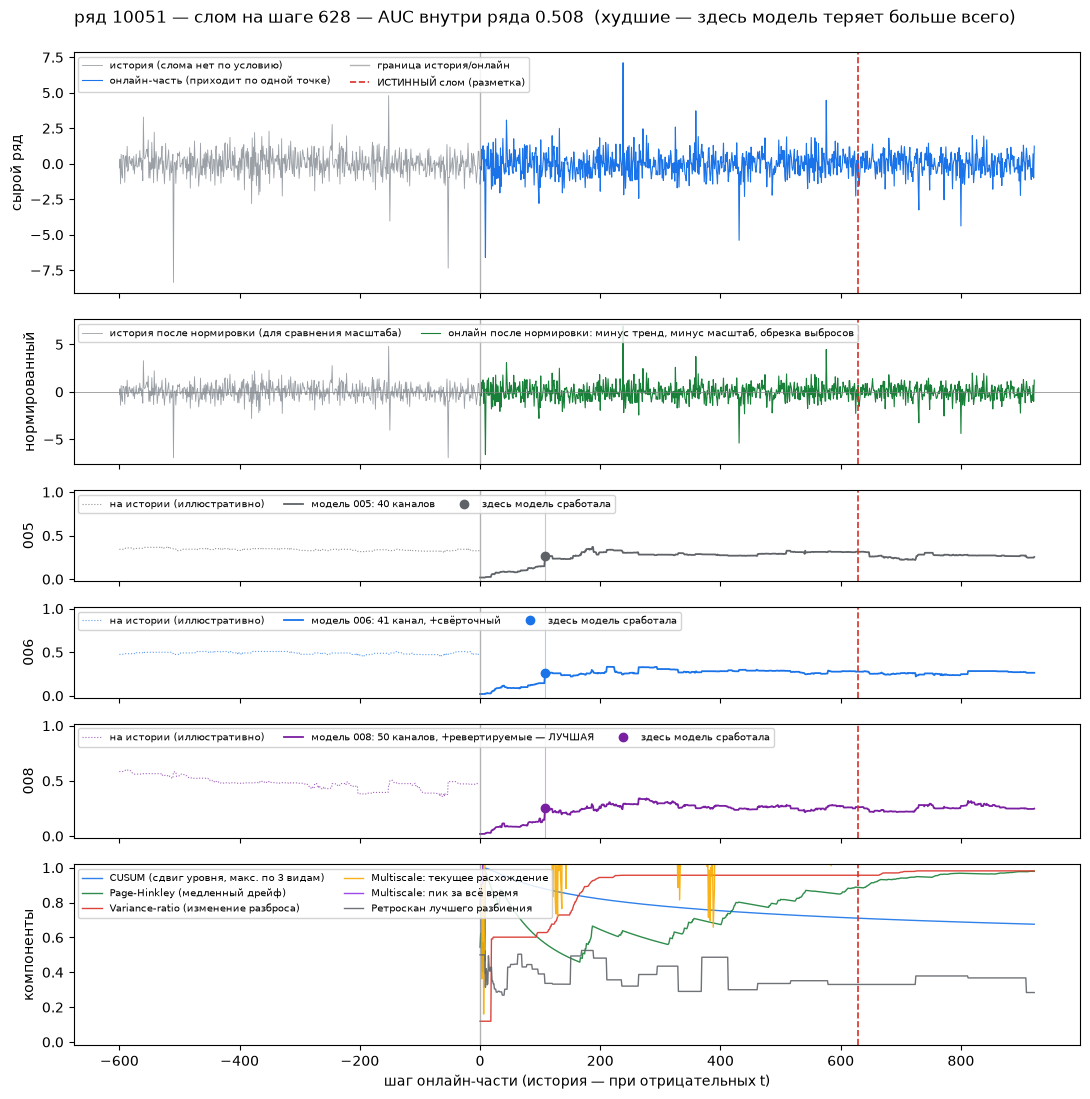

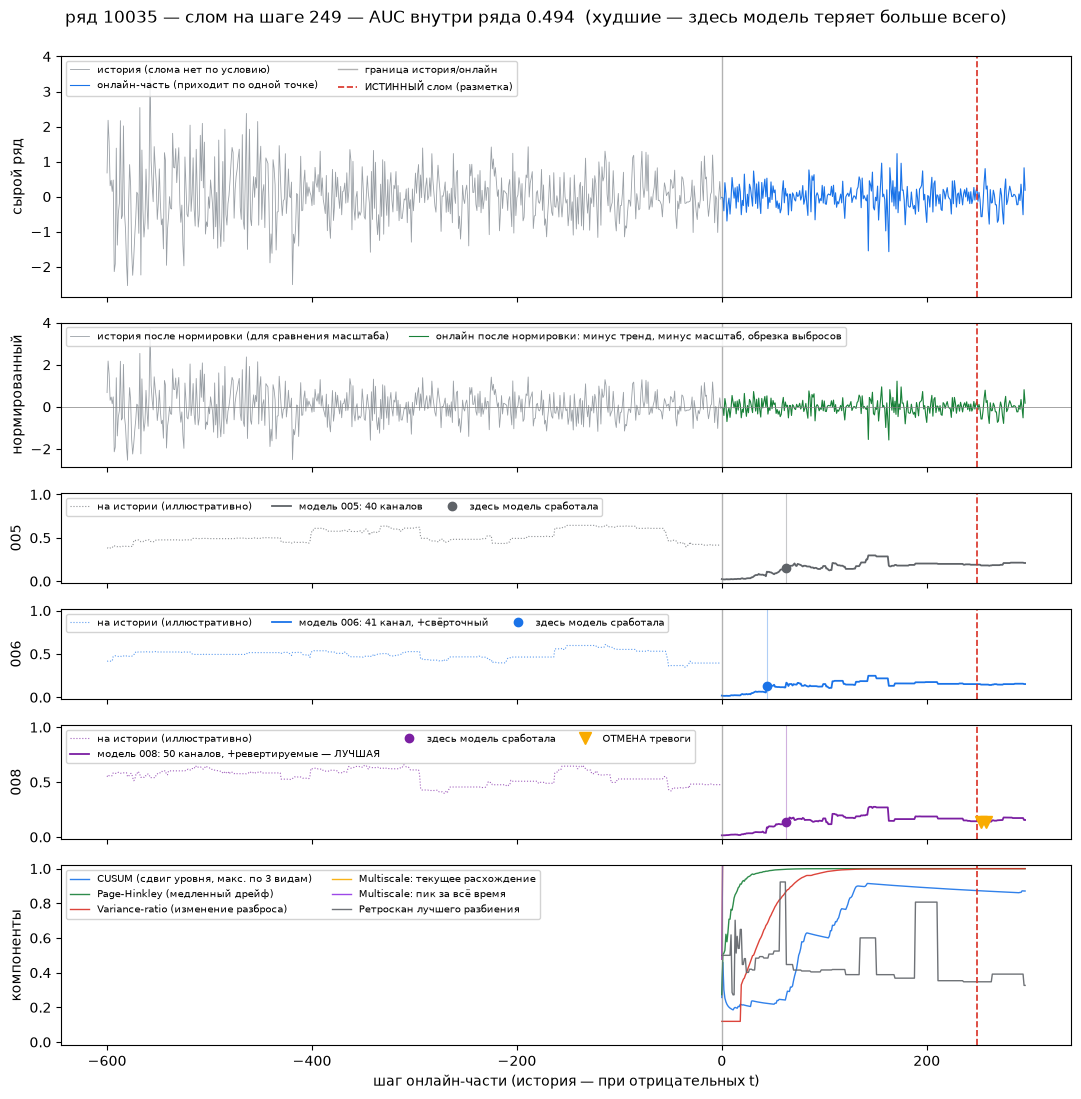

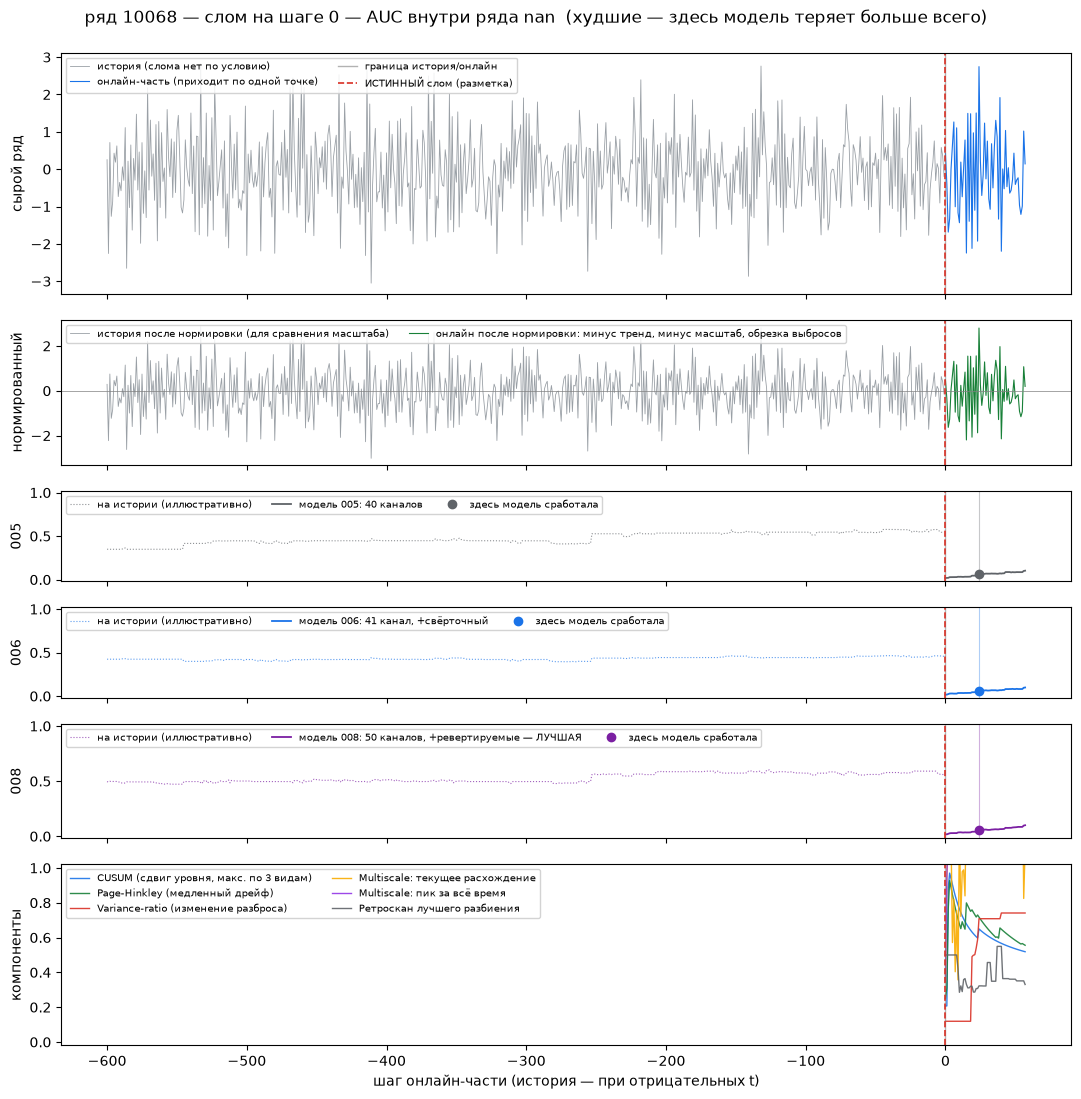

In [7]:
for sid in ids[-3:]:
    show(sid, "  (худшие — здесь модель теряет больше всего)")

## Ряды без слома: ложные тревоги

Красной линии не существует; всё, что счёт здесь делает, — ошибка. Три чистых
ряда с самым высоким финальным счётом — худшие ложные тревоги модели. Здесь же
видно главное умение 008: поднятая по ошибке тревога может быть отменена.

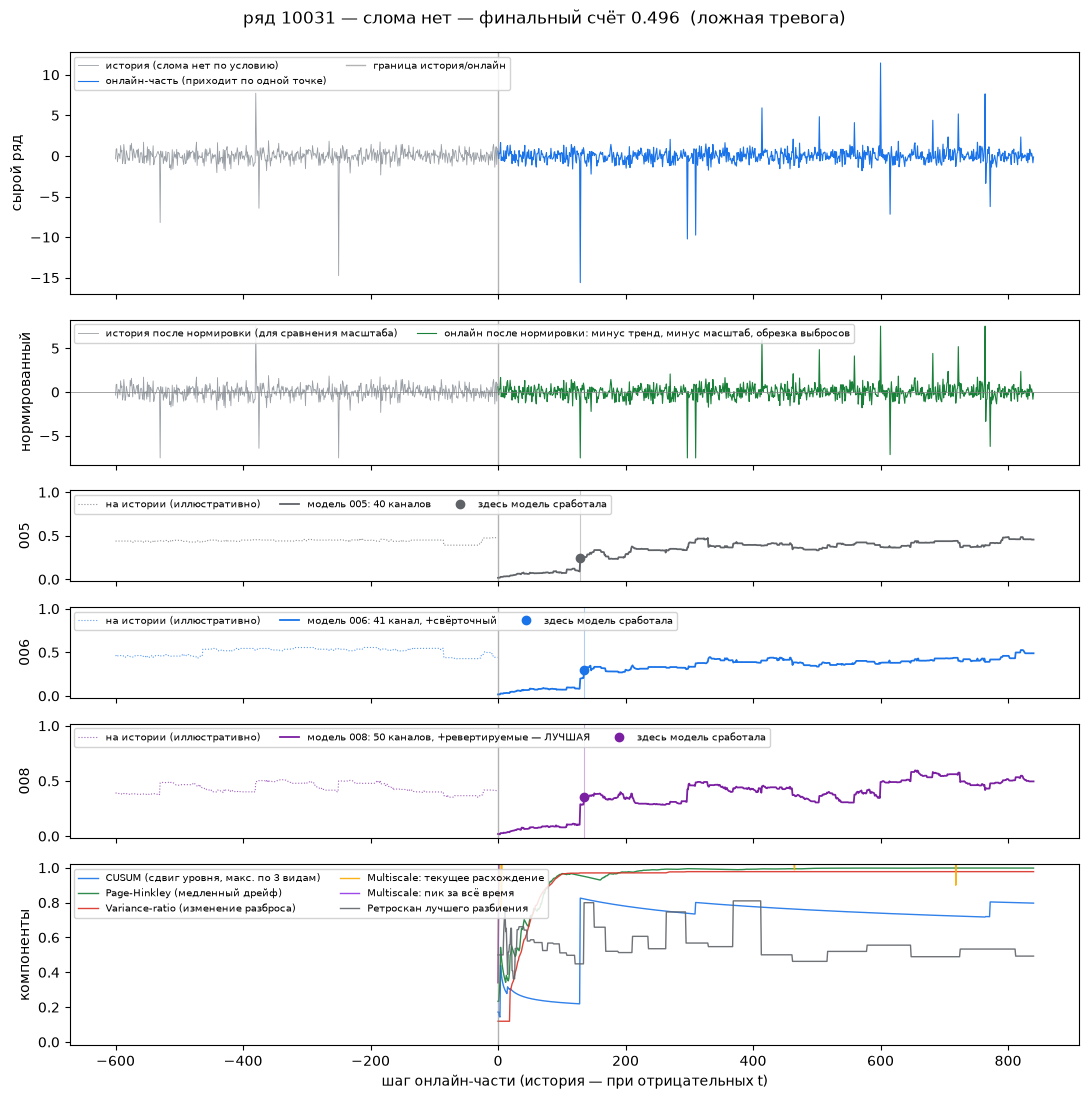

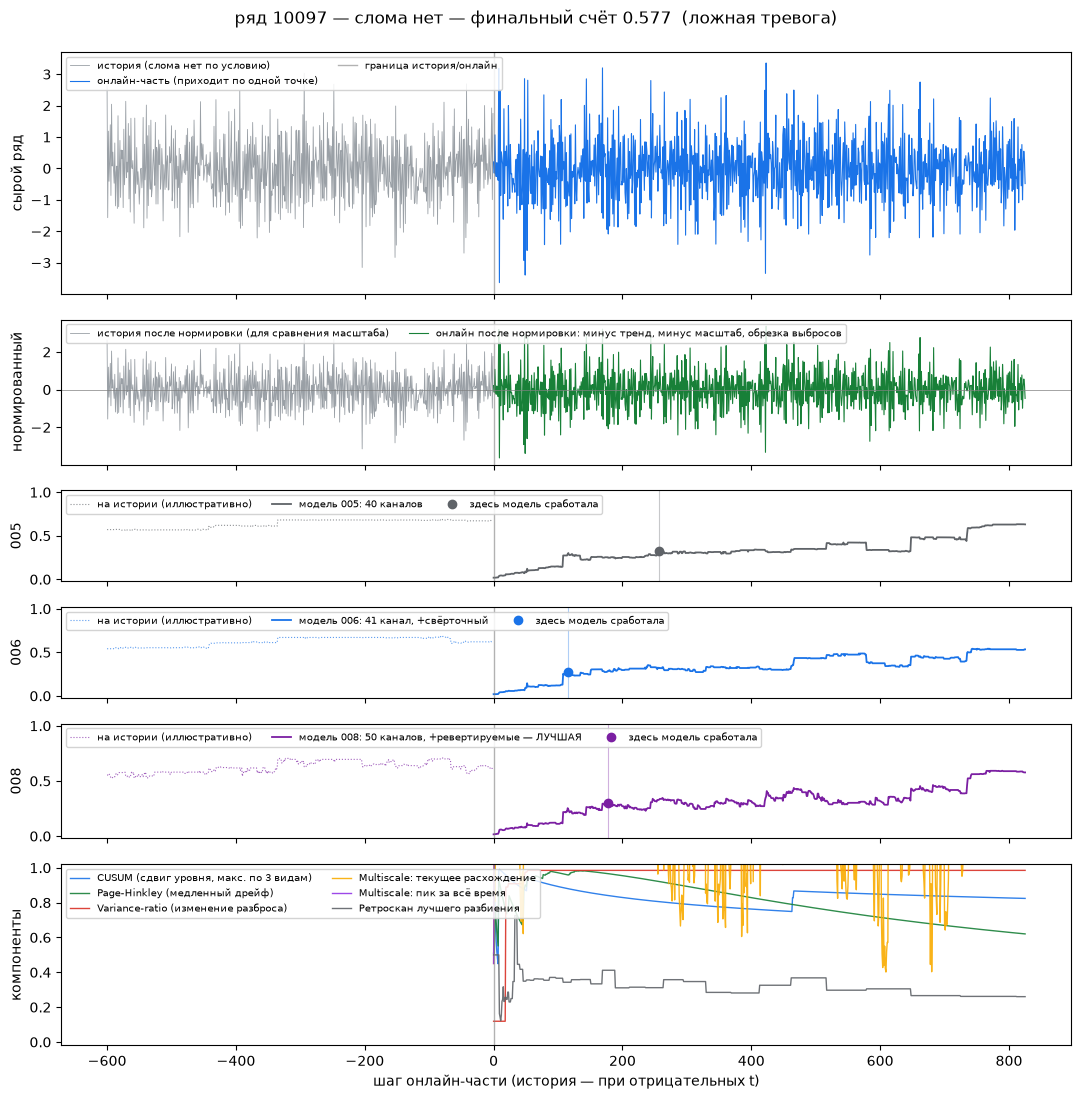

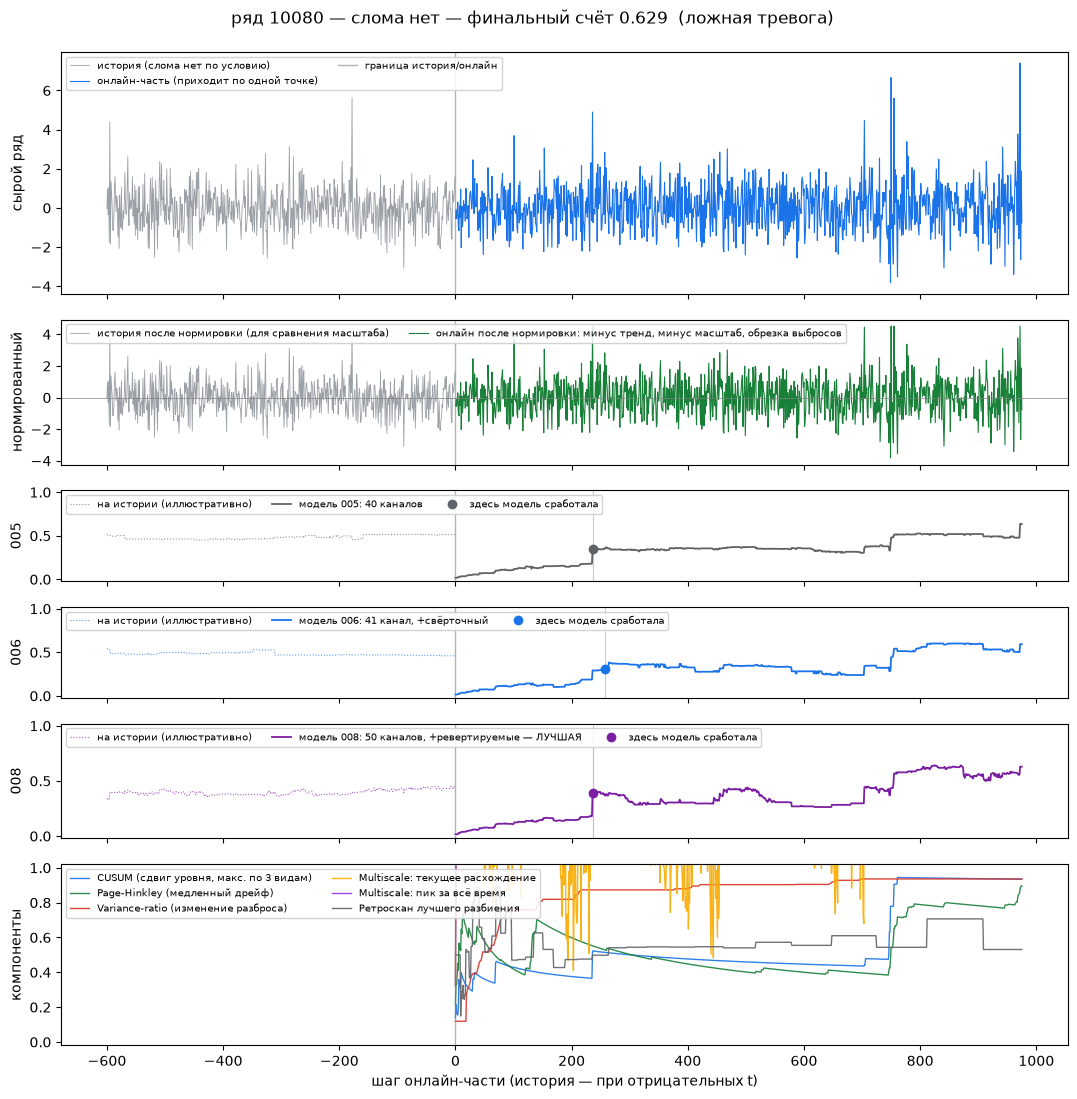

In [8]:
for sid in list(clean.index)[-3:]:
    show(sid, "  (ложная тревога)")

## Отмена тревоги в действии

Ряды, где счёт лучшей модели (008) поднялся — и спустился обратно: «а, нет,
это был не слом». Старые модели (005/006) этого не умеют: их каналы помнят
только пик подозрения, и на тех же полосах видно, как их счёт застревает
наверху. Именно эта разница дала +0.006 на кросс-валидации.

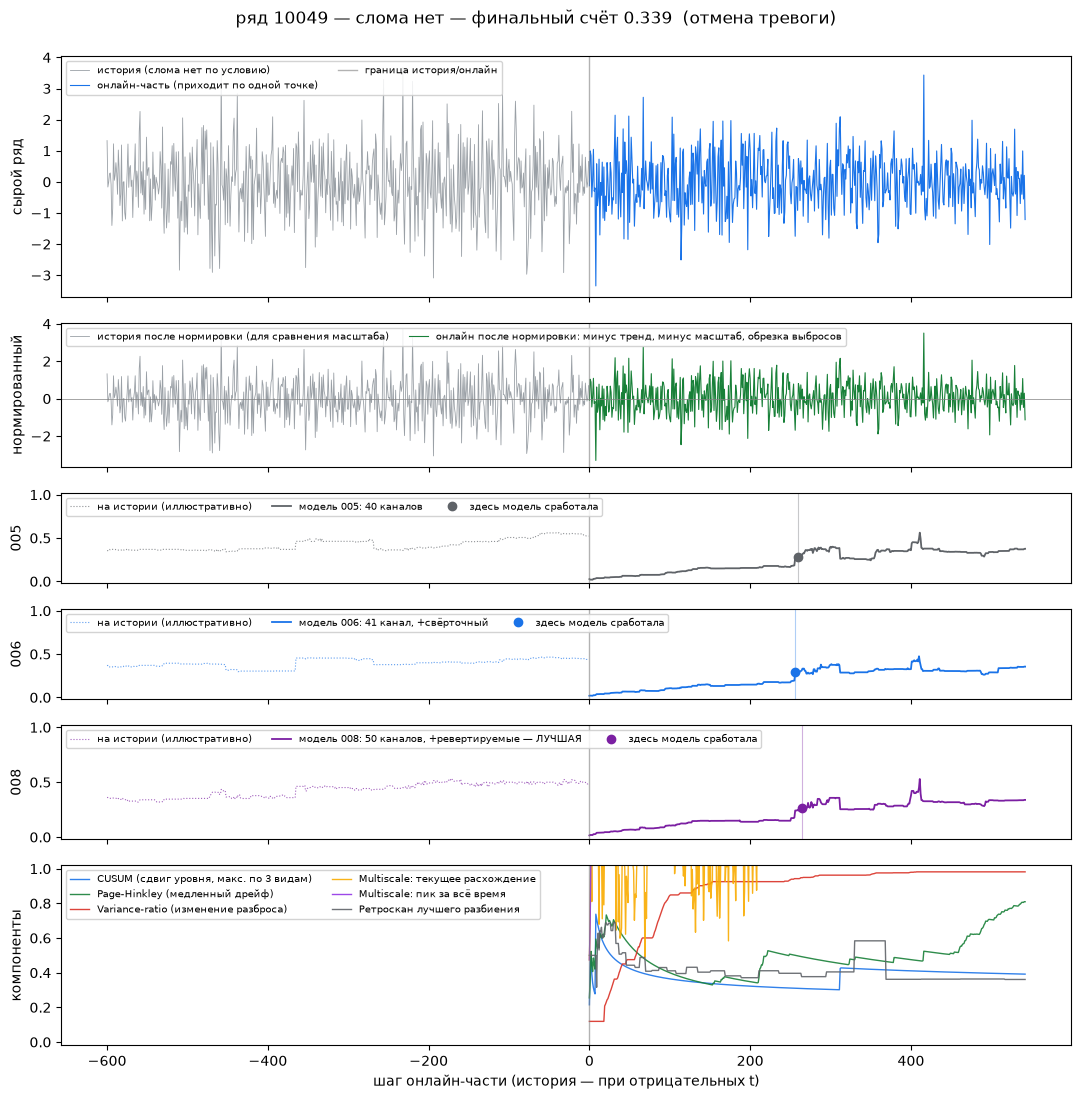

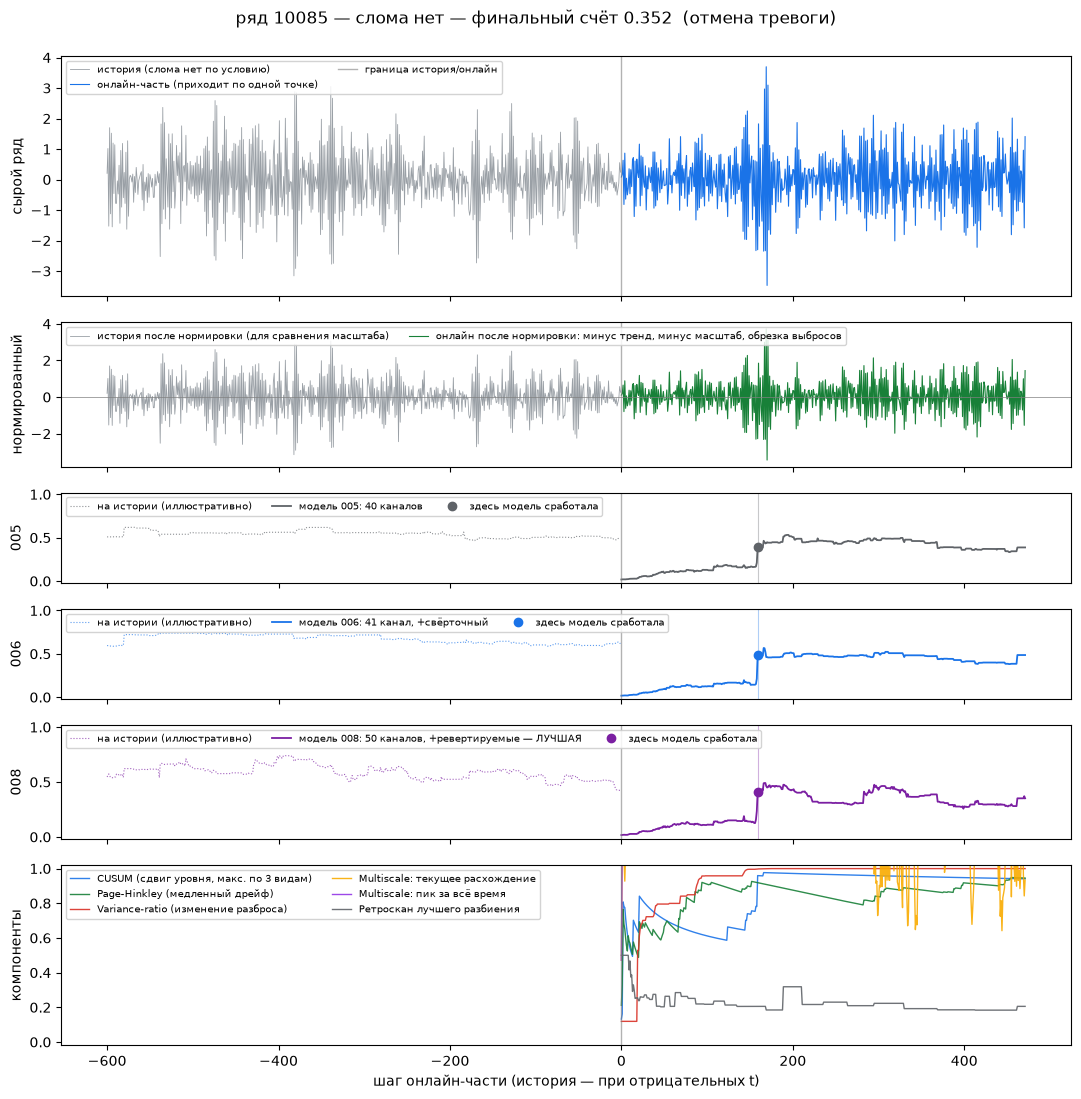

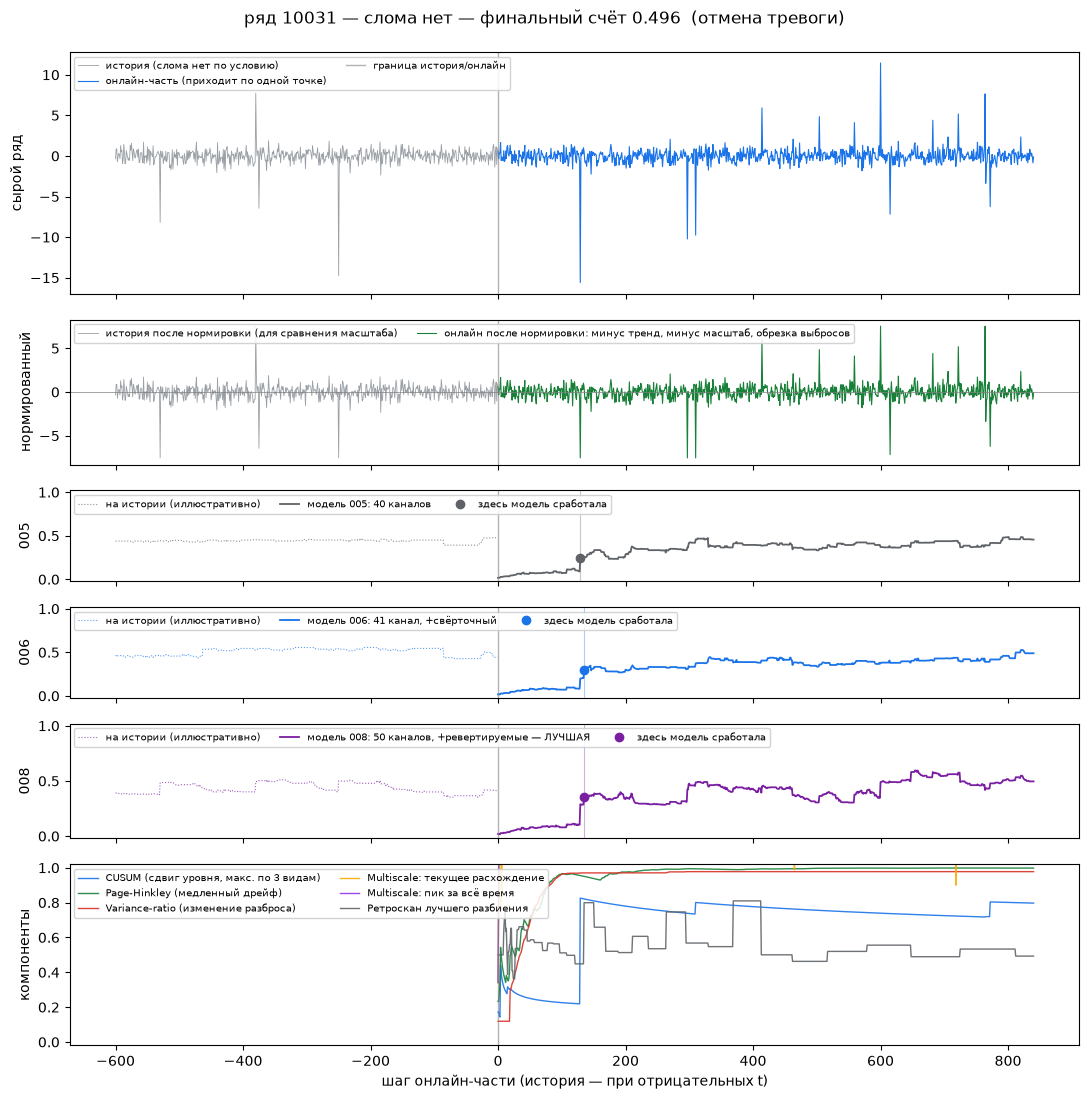

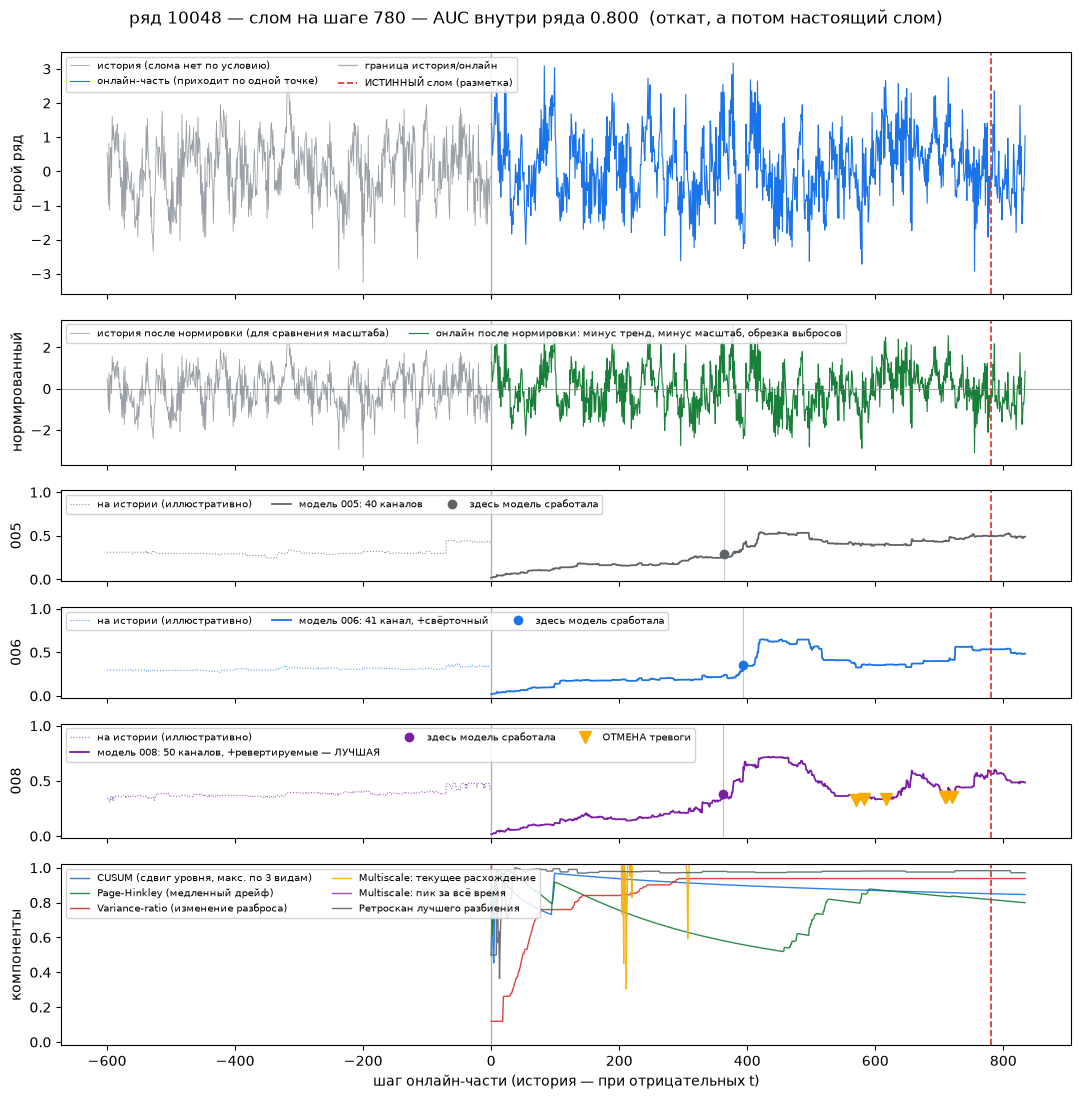

In [9]:
# Самый глубокий откат счёта 008 — три ряда без слома и, для контраста,
# один со сломом: откат до настоящего слома не мешает потом сработать.
deep_clean = table[~table.broken].sort_values("drawdown", ascending=False)
for sid in list(deep_clean.index)[:3]:
    show(sid, "  (отмена тревоги)")
deep_broken = table[table.broken].sort_values("drawdown", ascending=False)
for sid in list(deep_broken.index)[:1]:
    show(sid, "  (откат, а потом настоящий слом)")

## Какие ряды трудные

Медианный AUC внутри ряда (по рядам со сломом), с разбиением каждой оси на
половины по медиане. Большой зазор между столбиками — готовая гипотеза;
одинаковые столбики — эта ось не важна.

,нижняя половина,верхняя половина,порог (медиана)
сила тренда,0.955,0.992,0.051
разброс,0.990,0.955,1.000
автокорреляция,0.969,0.980,0.027
тяжесть хвостов,0.969,0.976,0.208
позиция слома,0.995,0.925,205.000
длина онлайн-части,0.993,0.927,498.000


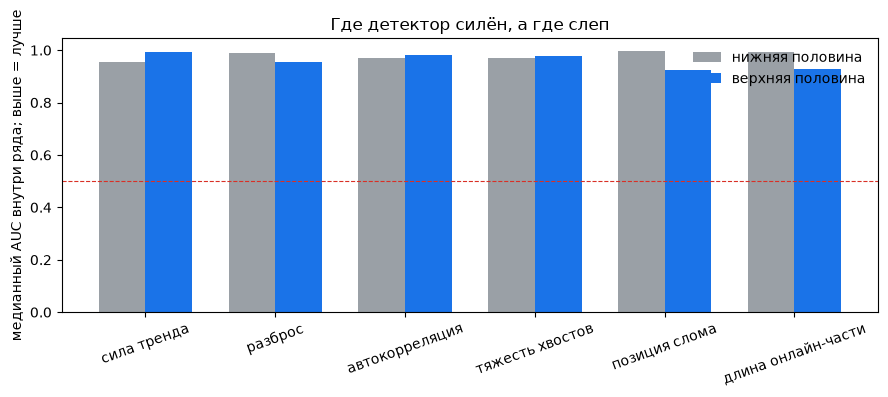

In [10]:
splits = {}
b = table[table.broken]
for col, name in [("trend", "сила тренда"), ("sd", "разброс"),
                  ("rho", "автокорреляция"), ("kurt", "тяжесть хвостов"),
                  ("tau", "позиция слома"), ("n_online", "длина онлайн-части")]:
    m = b[col].median()
    low, high = b[b[col] <= m], b[b[col] > m]
    splits[name] = (low.quality.median(), high.quality.median(), m)
frame = pd.DataFrame(splits, index=["нижняя половина", "верхняя половина", "порог (медиана)"]).T
display(frame.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
xpos = np.arange(len(frame))
ax.bar(xpos - 0.18, frame["нижняя половина"], width=0.36,
       label="нижняя половина", color="#9aa0a6")
ax.bar(xpos + 0.18, frame["верхняя половина"], width=0.36,
       label="верхняя половина", color="#1a73e8")
ax.set_xticks(xpos, frame.index, rotation=20)
ax.set_ylabel("медианный AUC внутри ряда; выше = лучше")
ax.axhline(0.5, color="#d93025", lw=0.8, ls="--")
ax.legend(frameon=False)
ax.set_title("Где детектор силён, а где слеп")
plt.tight_layout(); plt.show()

## Что читать из этого дальше

Столбики выше — генератор гипотез: каждая ось с видимым зазором — вопрос,
какой канал его закроет; каждая картинка из «худших» — конкретный ряд, о
котором стоит подумать. Блокнот пересобирается скриптом
`scripts/build_analysis_notebook.py`; правки — только там.